This notebook provides a guided tour of the codebase used to replicate Table 1 of Kelly & Pruitt (2013). The core of this analysis relies on constructing a single predictor (a latent factor) from a large cross-section of assets to forecast market returns.

We will walk through:

Data Ingestion & Cleaning: How we handle the raw Fama-French data.

Data Sparsity: Visualizing the availability of our cross-sectional predictors (the 6, 25, and 100 portfolios).

The Three-Pass Regression Filter: Visualizing the intermediate steps of the target-proxy algorithm.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
from pathlib import Path

# Import our custom modules
import load_data
import regression_tools as rt

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Data Ingestion & Cleaning
The raw Fama-French datasets contain missing value indicators such as -99.99, -999, -999.00, and -99.990. Our load_data.py script standardizes these to NaN and calculates the Monthly Book-to-Market (BM) ratios.

We apply a log transformation to the BM ratios, matching the methodology specified by Vuolteenaho.

In [6]:
# Load the cleaned data from our cache
print("Loading cleaned datasets...")
data = load_data.clean_kelly_pruitt_data(load_from_cache=True)

# Extract the Book-to-Market (BM) DataFrames
bm_6 = data["6_Portfolios_2x3_BM"]
bm_25 = data["25_Portfolios_5x5_BM"]
bm_100 = data["100_Portfolios_10x10_BM"]

print(f"Data spans from {bm_25.index.min().date()} to {bm_25.index.max().date()}")

Loading cleaned datasets...
Data spans from 1932-01-01 to 2010-12-01


## Analyzing Data Sparsity
When dealing with large cross-sections (like the 100 Portfolios formed on Size and Book-to-Market), not all portfolios have data going back to the beginning of the sample. To understand our cross-sectional sample size over time, we can plot the number of non-null portfolios available in each dataset for every month.

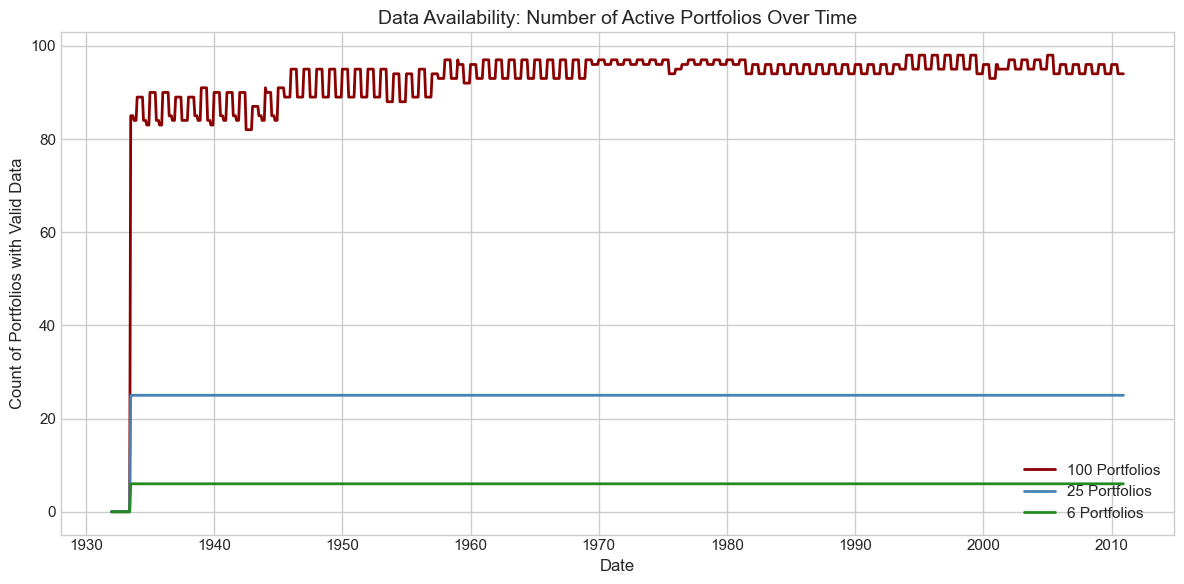

In [7]:
# Calculate the number of non-NaN observations per month
valid_6 = bm_6.count(axis=1)
valid_25 = bm_25.count(axis=1)
valid_100 = bm_100.count(axis=1)

# Plotting the sparsity/availability
plt.figure(figsize=(12, 6))
plt.plot(valid_100.index, valid_100, label="100 Portfolios", color='darkred', linewidth=2)
plt.plot(valid_25.index, valid_25, label="25 Portfolios", color='steelblue', linewidth=2)
plt.plot(valid_6.index, valid_6, label="6 Portfolios", color='forestgreen', linewidth=2)

plt.title("Data Availability: Number of Active Portfolios Over Time", fontsize=14)
plt.ylabel("Count of Portfolios with Valid Data", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## The Three-Pass Regression Filter (Intermediate Steps)
The magic of the Kelly & Pruitt (2013) approach is extracting a single predictive factor, $F_t$, from the cross-section of Book-to-Market ratios.

Let's use the 25 Portfolios and a 1-month forecast horizon ($h=1$) to visualize the intermediate outputs of regression_tools.py.

In [8]:
# Define our target variable (1-Month Log Market Returns)
y_1m = data['Market_Returns']['Log_Mkt']
v_df = bm_25  # The cross-section of predictors

# Align data indices
common_idx = v_df.index.intersection(y_1m.index)
v_df = v_df.loc[common_idx]
y_1m = y_1m.loc[common_idx]

### Stage 1: Time-Series Regressions (Estimating Sensitivities)

First, we run a time-series regression for each portfolio $i$ to estimate its sensitivity to future market returns.

We regress the portfolio's characteristic $v_{i,t}$ on the future market return $y_{t+h}$:$$v_{i,t} = \phi_{i,0} + \phi_i y_{t+h} + e_{i,t}$$

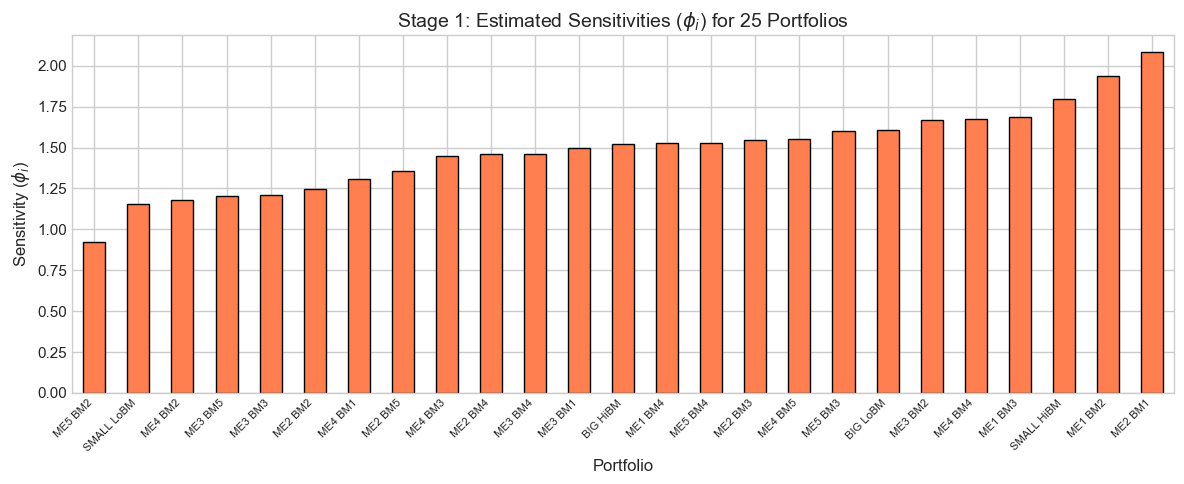

In [9]:
# Run Stage 1
phi = rt.first_stage_regressions(v_df, y_1m, h=1)

# Visualize the cross-section of sensitivities (phi)
plt.figure(figsize=(12, 5))
phi.sort_values().plot(kind='bar', color='coral', edgecolor='black')
plt.title("Stage 1: Estimated Sensitivities ($\phi_i$) for 25 Portfolios", fontsize=14)
plt.ylabel("Sensitivity ($\phi_i$)", fontsize=12)
plt.xlabel("Portfolio", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### Stage 2: Cross-Sectional Regressions (Extracting the Factor)

Next, at each time step $t$, we run a cross-sectional regression of the portfolio characteristics $v_{i,t}$ onto their estimated sensitivities $\phi_i$:$$v_{i,t} = c_t + F_t \phi_i + w_{i,t}$$

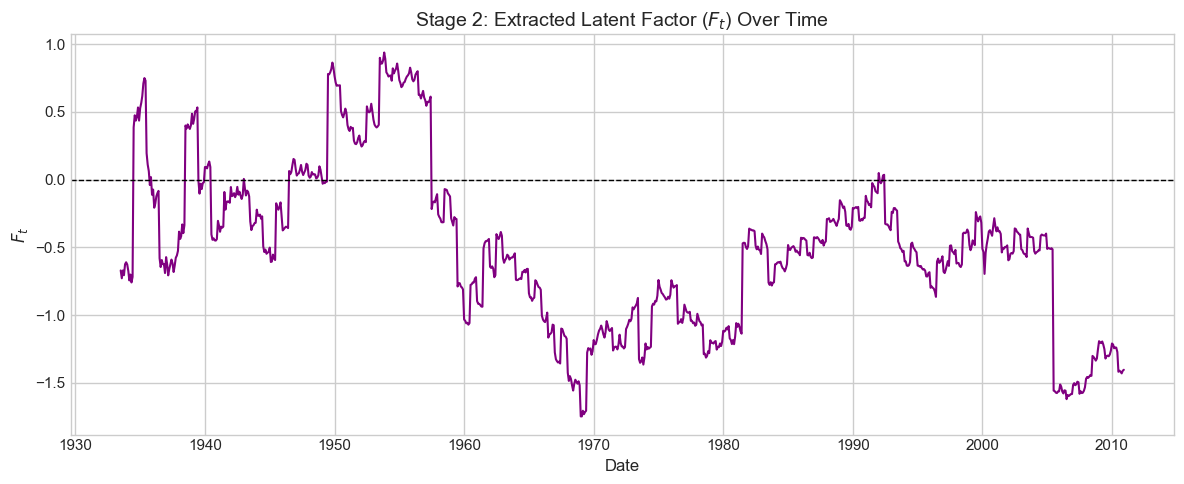

In [10]:
# Run Stage 2
F_series = rt.second_stage_regressions(v_df, phi)

# Visualize the extracted Latent Factor over time
plt.figure(figsize=(12, 5))
plt.plot(F_series.index, F_series, color='purple', linewidth=1.5)
plt.title("Stage 2: Extracted Latent Factor ($F_t$) Over Time", fontsize=14)
plt.ylabel("$F_t$", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

### Stage 3: Predictive Regression

Finally, we regress future market returns on our newly extracted, lagged factor $F_t$ to build our prediction model.$$y_{t+h} = \beta_0 + \beta F_t + u_{t+h}$$

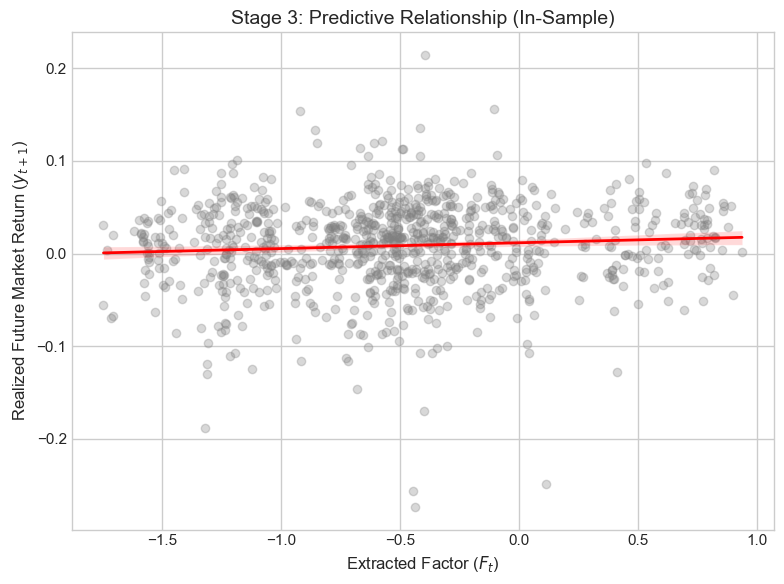

In [12]:
# Run Stage 3
model = rt.third_stage_regression(F_series, y_1m, h=1)

# Create a scatter plot of F_t vs realized future returns
# Shift y backwards to align F_t with the y it is trying to predict
df_plot = pd.concat([F_series.rename('F_t'), y_1m.shift(-1).rename('Future_Mkt_Ret')], axis=1).dropna()

plt.figure(figsize=(8, 6))
plt_sns.regplot(
    x='F_t', y='Future_Mkt_Ret', data=df_plot, 
    scatter_kws={'alpha': 0.3, 'color': 'gray'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title("Stage 3: Predictive Relationship (In-Sample)", fontsize=14)
plt.xlabel("Extracted Factor ($F_t$)", fontsize=12)
plt.ylabel("Realized Future Market Return ($y_{t+1}$)", fontsize=12)
plt.tight_layout()
plt.show()